In [6]:
pip install torch 

  Using cached torch-2.14.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.7-py3-none-any.whl.metadata (6.7 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached cuda_bindings-13.4.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached nvidia_cudnn_cu13-9.24.0.43-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (978 bytes)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Usi

In [7]:
import torch

print(torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.14.1+cu130
CUDA: True
NVIDIA GeForce RTX 4070 Ti SUPER


In [9]:
import os, sys, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)


Python: /home/adminbum/ntqai/.venv/bin/python
PyTorch: 2.14.1+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
CUDA: 13.0


In [20]:
ROOT = Path("/mnt/d/Data/VNTM3/_stft30_v1")
FEATURE_DIR = ROOT / "features"
REPORT_DIR = ROOT / "reports"

RUN_DIR = Path("/mnt/d/Data/VNTM3/_cnn2d_stft_v1")
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
FIGURE_DIR = RUN_DIR / "figures"
RESULT_DIR = RUN_DIR / "results"

for p in [RUN_DIR, CHECKPOINT_DIR, FIGURE_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

FEATURE_MANIFEST = REPORT_DIR / "stft_feature_manifest.csv"


SEED = 42



INPUT_H = 256
INPUT_W = 320


BATCH_SIZE = 64
NUM_WORKERS = 12
EPOCHS = 50

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4


INPUT_H = 256
INPUT_W = 320

PATIENCE = 10
MIN_DELTA = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)
print("Run directory:", RUN_DIR)


Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER
VRAM: 15.99 GB
Batch size: 64
Workers: 12
Run directory: /mnt/d/Data/VNTM3/_cnn2d_stft_v1


In [22]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Seed:", SEED)
print("cuDNN benchmark:", torch.backends.cudnn.benchmark)


Seed: 42
cuDNN benchmark: True


In [23]:
df = pd.read_csv(FEATURE_MANIFEST)

required = {"split", "label", "feature_path"}
missing = required - set(df.columns)

if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Files:", len(df))

display(
    df.groupby(["label", "split"])
    .size()
    .unstack(fill_value=0)
)

classes = sorted(df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

NUM_CLASSES = len(classes)

print("\nClasses:")
for k, v in class_to_idx.items():
    print(v, "->", k)

assert NUM_CLASSES == 5


Files: 2495


split,test,train,valid
label,,,
cailuong,75,350,75
catru,75,347,74
chauvan,75,349,75
cheo,75,350,75
hatxam,75,350,75



Classes:
0 -> cailuong
1 -> catru
2 -> chauvan
3 -> cheo
4 -> hatxam


In [24]:
class STFTDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_idx,
        train=False,
        target_hw=(256, 320)
    ):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.train = train
        self.target_hw = target_hw

    def __len__(self):
        return len(self.df)

    def _augment(self, x):
        

        
        if random.random() < 0.50:
            max_shift = max(1, x.shape[-1] // 20)
            shift = random.randint(-max_shift, max_shift)
            x = torch.roll(x, shifts=shift, dims=-1)

        
        if random.random() < 0.50:
            max_width = max(1, x.shape[-2] // 12)
            width = random.randint(1, max_width)
            start = random.randint(0, x.shape[-2] - width)
            x[:, start:start+width, :] = 0.0

        
        if random.random() < 0.50:
            max_width = max(1, x.shape[-1] // 10)
            width = random.randint(1, max_width)
            start = random.randint(0, x.shape[-1] - width)
            x[:, :, start:start+width] = 0.0

        
        if random.random() < 0.40:
            scale = random.uniform(0.90, 1.10)
            x = torch.clamp(x * scale, 0.0, 1.0)

        return x

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        arr = np.load(row["feature_path"]).astype(np.float32)

        
        x = torch.from_numpy(arr).unsqueeze(0)

        
        x = F.interpolate(
            x.unsqueeze(0),
            size=self.target_hw,
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        if self.train:
            x = self._augment(x)

        y = self.class_to_idx[row["label"]]

        return x, y, idx


In [25]:
train_df = df[df["split"] == "train"].copy()
valid_df = df[df["split"] == "valid"].copy()
test_df  = df[df["split"] == "test"].copy()

train_ds = STFTDataset(
    train_df, class_to_idx,
    train=True,
    target_hw=(INPUT_H, INPUT_W)
)

valid_ds = STFTDataset(
    valid_df, class_to_idx,
    train=False,
    target_hw=(INPUT_H, INPUT_W)
)

test_ds = STFTDataset(
    test_df, class_to_idx,
    train=False,
    target_hw=(INPUT_H, INPUT_W)
)

pin = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=(NUM_WORKERS > 0)
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Train:", len(train_ds))
print("Valid:", len(valid_ds))
print("Test :", len(test_ds))

xb, yb, ib = next(iter(train_loader))
print("Batch X:", xb.shape)
print("Batch y:", yb.shape)
print("Range:", float(xb.min()), "->", float(xb.max()))


Train: 1746
Valid: 374
Test : 375
Batch X: torch.Size([64, 1, 256, 320])
Batch y: torch.Size([64])
Range: 0.0 -> 1.0


In [26]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        ]

        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CNN2D_STFT(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(1, 32, 0.05),
            ConvBlock(32, 64, 0.10),
            ConvBlock(64, 128, 0.15),
            ConvBlock(128, 192, 0.20)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = CNN2D_STFT(NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nParameters: {n_params:,}")
print(f"Trainable : {trainable:,}")


CNN2D_STFT(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=

In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Loss: CrossEntropyLoss")
print("Optimizer: AdamW")
print("LR:", LEARNING_RATE)


Loss: CrossEntropyLoss
Optimizer: AdamW
LR: 0.0003


In [28]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(acc),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1)
    }

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_true = []
    all_pred = []

    for x, y, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE.type == "cuda")
            ):
                logits = model(x)
                loss = criterion(logits, y)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)

        all_true.extend(
            y.detach().cpu().numpy().tolist()
        )

        all_pred.extend(
            pred.detach().cpu().numpy().tolist()
        )

    metrics = compute_metrics(
        all_true,
        all_pred
    )

    metrics["loss"] = (
        total_loss / len(loader.dataset)
    )

    return metrics

In [29]:
history = []
best_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

best_path = CHECKPOINT_DIR / "best_cnn2d_stft.pt"

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    train_metrics = run_epoch(
        model, train_loader, criterion, optimizer
    )

    valid_metrics = run_epoch(
        model, valid_loader, criterion
    )

    scheduler.step(valid_metrics["macro_f1"])

    lr_now = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": lr_now,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"valid_{k}": v for k, v in valid_metrics.items()}
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f} "
        f"acc={train_metrics['accuracy']:.4f} "
        f"F1={train_metrics['macro_f1']:.4f} | "
        f"valid loss={valid_metrics['loss']:.4f} "
        f"acc={valid_metrics['accuracy']:.4f} "
        f"F1={valid_metrics['macro_f1']:.4f} | "
        f"lr={lr_now:.2e}"
    )

    current_f1 = valid_metrics["macro_f1"]

    if current_f1 > best_f1 + MIN_DELTA:
        best_f1 = current_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "valid_metrics": valid_metrics,
            "classes": classes,
            "class_to_idx": class_to_idx,
            "input_hw": [INPUT_H, INPUT_W],
            "config": {
                "seed": SEED,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "n_fft": 2048,
                "hop_length": 512
            }
        }, best_path)

        print(f"  ✓ saved best checkpoint (macro-F1={best_f1:.4f})")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}. "
            f"Best epoch = {best_epoch}."
        )
        break

elapsed = time.time() - start_time

history_df = pd.DataFrame(history)
history_df.to_csv(
    RESULT_DIR / "training_history.csv",
    index=False
)

print(f"\nTraining time: {elapsed/60:.1f} min")
print("Best epoch:", best_epoch)
print("Best validation macro-F1:", round(best_f1, 4))
print("Checkpoint:", best_path)


Epoch 01/50 | train loss=1.2980 acc=0.4914 F1=0.4746 | valid loss=1.5716 acc=0.3529 F1=0.2206 | lr=3.00e-04
  ✓ saved best checkpoint (macro-F1=0.2206)
Epoch 02/50 | train loss=0.9780 acc=0.6254 F1=0.6041 | valid loss=1.0762 acc=0.5695 F1=0.5164 | lr=3.00e-04
  ✓ saved best checkpoint (macro-F1=0.5164)
Epoch 03/50 | train loss=0.8279 acc=0.6919 F1=0.6825 | valid loss=0.6893 acc=0.7754 F1=0.7685 | lr=3.00e-04
  ✓ saved best checkpoint (macro-F1=0.7685)
Epoch 04/50 | train loss=0.7089 acc=0.7194 F1=0.7181 | valid loss=0.8317 acc=0.6364 F1=0.6160 | lr=3.00e-04
Epoch 05/50 | train loss=0.6628 acc=0.7463 F1=0.7450 | valid loss=0.4677 acc=0.8075 F1=0.8029 | lr=3.00e-04
  ✓ saved best checkpoint (macro-F1=0.8029)
Epoch 06/50 | train loss=0.6038 acc=0.7738 F1=0.7735 | valid loss=0.4386 acc=0.8342 F1=0.8276 | lr=3.00e-04
  ✓ saved best checkpoint (macro-F1=0.8276)
Epoch 07/50 | train loss=0.5495 acc=0.7944 F1=0.7927 | valid loss=0.3902 acc=0.8529 F1=0.8515 | lr=3.00e-04
  ✓ saved best checkpoin

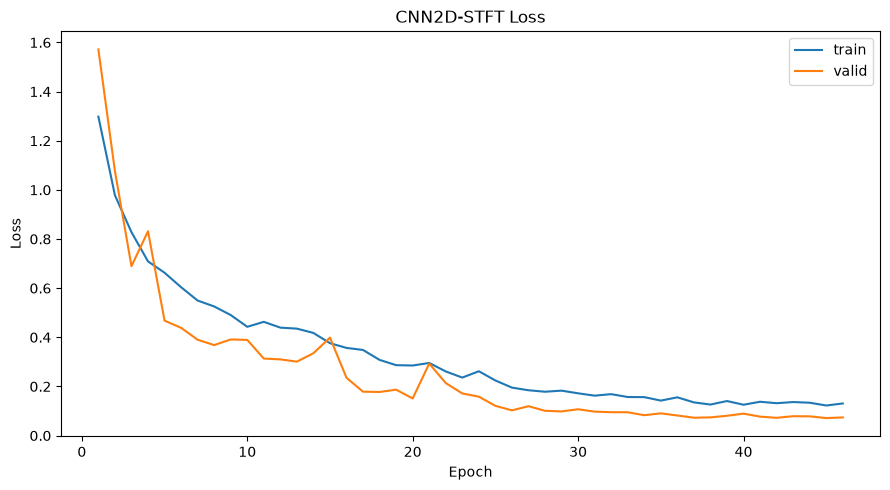

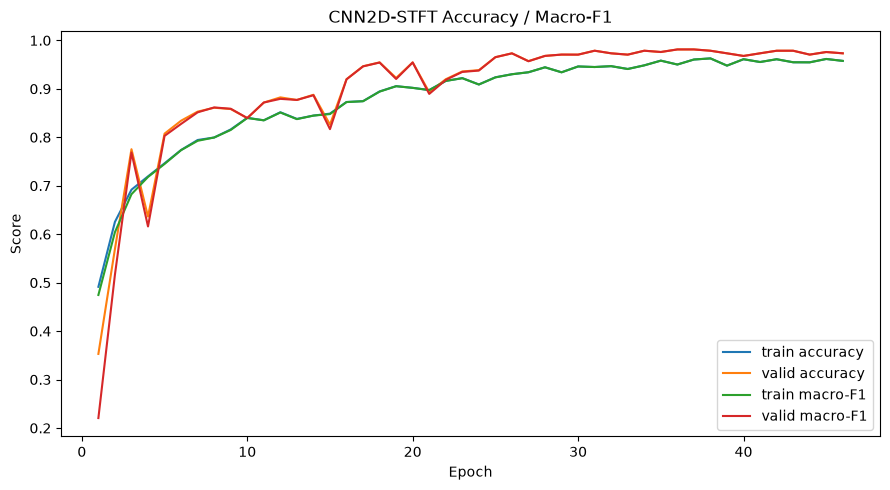

In [30]:
fig = plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="valid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN2D-STFT Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "loss_curve.png", dpi=160)
plt.show()

fig = plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="train accuracy")
plt.plot(history_df["epoch"], history_df["valid_accuracy"], label="valid accuracy")
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train macro-F1")
plt.plot(history_df["epoch"], history_df["valid_macro_f1"], label="valid macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("CNN2D-STFT Accuracy / Macro-F1")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "metric_curves.png", dpi=160)
plt.show()


In [31]:
checkpoint = torch.load(
    best_path,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best epoch:", checkpoint["epoch"])
print("Best valid metrics:")
print(checkpoint["valid_metrics"])


Loaded best epoch: 36
Best valid metrics:
{'accuracy': 0.9812834224598931, 'macro_precision': 0.9818839055681161, 'macro_recall': 0.9812252252252252, 'macro_f1': 0.98127120647901, 'loss': 0.0817830491273161}


In [32]:
@torch.no_grad()
def predict_full(model, loader):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []
    all_dataset_idx = []

    for x, y, idx in tqdm(loader, desc="Test inference"):
        x = x.to(DEVICE, non_blocking=True)

        logits = model(x)
        prob = torch.softmax(logits, dim=1)
        pred = prob.argmax(dim=1)

        all_true.extend(y.numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob.append(prob.cpu().numpy())
        all_dataset_idx.extend(idx.numpy().tolist())

    return (
        np.array(all_true),
        np.array(all_pred),
        np.concatenate(all_prob, axis=0),
        np.array(all_dataset_idx)
    )


y_true, y_pred, y_prob, dataset_idx = predict_full(
    model, test_loader
)

test_metrics = compute_metrics(y_true, y_pred)

print("TEST METRICS")
for k, v in test_metrics.items():
    print(f"{k:16s}: {v:.4f}")


Test inference: 100%|██████████| 6/6 [00:07<00:00,  1.26s/it]

TEST METRICS
accuracy        : 0.9787
macro_precision : 0.9796
macro_recall    : 0.9787
macro_f1        : 0.9785


In [33]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
display(report_df.round(4))

report_df.to_csv(
    RESULT_DIR / "classification_report.csv",
    encoding="utf-8-sig"
)


,precision,recall,f1-score,support
cailuong,1.0000,0.9067,0.9510,75.0000
catru,1.0000,1.0000,1.0000,75.0000
chauvan,0.9375,1.0000,0.9677,75.0000
cheo,0.9868,1.0000,0.9934,75.0000
hatxam,0.9737,0.9867,0.9801,75.0000
accuracy,0.9787,0.9787,0.9787,0.9787
macro avg,0.9796,0.9787,0.9785,375.0000
weighted avg,0.9796,0.9787,0.9785,375.0000


,cailuong,catru,chauvan,cheo,hatxam
cailuong,68,0,4,1,2
catru,0,75,0,0,0
chauvan,0,0,75,0,0
cheo,0,0,0,75,0
hatxam,0,0,1,0,74


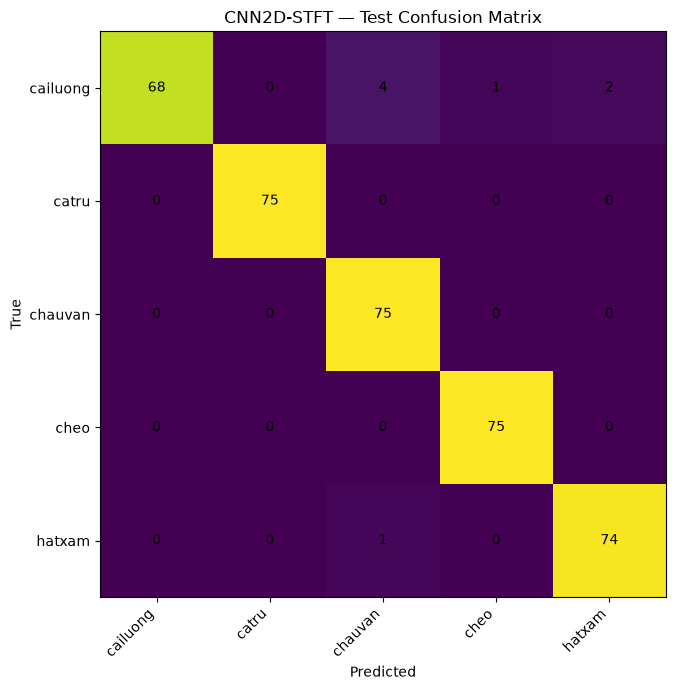

In [34]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

display(cm_df)

cm_df.to_csv(
    RESULT_DIR / "confusion_matrix.csv",
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("CNN2D-STFT — Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), classes, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), classes)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center"
        )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "confusion_matrix.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()


In [35]:
pred_rows = []

for n, ds_idx in enumerate(dataset_idx):
    row = test_df.iloc[int(ds_idx)]

    item = {
        "filename": row["filename"],
        "label": row["label"],
        "true_id": int(y_true[n]),
        "predicted_label": idx_to_class[int(y_pred[n])],
        "predicted_id": int(y_pred[n]),
        "correct": bool(y_true[n] == y_pred[n]),
        "confidence": float(np.max(y_prob[n]))
    }

    for class_id, class_name in idx_to_class.items():
        item[f"prob_{class_name}"] = float(y_prob[n, class_id])

    pred_rows.append(item)

predictions_df = pd.DataFrame(pred_rows)

predictions_df.to_csv(
    RESULT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Correct:", int(predictions_df["correct"].sum()))
print("Wrong  :", int((~predictions_df["correct"]).sum()))

display(
    predictions_df[
        ~predictions_df["correct"]
    ].sort_values(
        "confidence",
        ascending=False
    ).head(30)
)


Correct: 367
Wrong  : 8


,filename,label,true_id,predicted_label,predicted_id,correct,confidence,prob_cailuong,prob_catru,prob_chauvan,prob_cheo,prob_hatxam
37,CaiLuong.445.wav,cailuong,0,cheo,3,False,0.890567,0.108097,0.000020,0.000035,0.890567,0.001281
266,CaiLuong.252.wav,cailuong,0,hatxam,4,False,0.691918,0.301067,0.000693,0.005140,0.001182,0.691918
290,CaiLuong.001.wav,cailuong,0,chauvan,2,False,0.658269,0.218749,0.009933,0.658269,0.015323,0.097726
350,Xam.263.wav,hatxam,4,chauvan,2,False,0.658208,0.105040,0.003904,0.658208,0.004015,0.228834
293,CaiLuong.470.wav,cailuong,0,chauvan,2,False,0.622797,0.354840,0.000582,0.622797,0.004693,0.017089
368,CaiLuong.008.wav,cailuong,0,chauvan,2,False,0.518014,0.295008,0.002611,0.518014,0.028991,0.155376
171,CaiLuong.488.wav,cailuong,0,chauvan,2,False,0.458815,0.396839,0.002656,0.458815,0.001528,0.140161
127,CaiLuong.482.wav,cailuong,0,hatxam,4,False,0.439489,0.405763,0.007365,0.144012,0.003370,0.439489


In [36]:
summary = {
    "experiment": "CNN2D_STFT_30s_v1",
    "seed": SEED,
    "classes": classes,
    "n_train": len(train_df),
    "n_valid": len(valid_df),
    "n_test": len(test_df),
    "original_stft_shape": [1025, 1292],
    "cnn_input_shape": [1, INPUT_H, INPUT_W],
    "augmentation_train_only": True,
    "best_epoch": int(best_epoch),
    "best_valid_macro_f1": float(best_f1),
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_precision": test_metrics["macro_precision"],
    "test_macro_recall": test_metrics["macro_recall"],
    "test_macro_f1": test_metrics["macro_f1"],
    "parameters": int(n_params),
    "training_minutes": float(elapsed / 60.0)
}

with open(
    RESULT_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "experiment": "CNN2D_STFT_30s_v1",
  "seed": 42,
  "classes": [
    "cailuong",
    "catru",
    "chauvan",
    "cheo",
    "hatxam"
  ],
  "n_train": 1746,
  "n_valid": 374,
  "n_test": 375,
  "original_stft_shape": [
    1025,
    1292
  ],
  "cnn_input_shape": [
    1,
    256,
    320
  ],
  "augmentation_train_only": true,
  "best_epoch": 36,
  "best_valid_macro_f1": 0.98127120647901,
  "test_accuracy": 0.9786666666666667,
  "test_macro_precision": 0.9796052631578946,
  "test_macro_recall": 0.9786666666666667,
  "test_macro_f1": 0.9784601640615312,
  "parameters": 865957,
  "training_minutes": 10.354301365216573
}


In [37]:
print("=" * 72)
print("CNN2D-STFT 30s — FINAL")
print("=" * 72)
print(f"Best epoch        : {best_epoch}")
print(f"Best valid F1     : {best_f1:.4f}")
print(f"Test accuracy     : {test_metrics['accuracy']:.4f}")
print(f"Test macro-F1     : {test_metrics['macro_f1']:.4f}")
print(f"Test macro-recall : {test_metrics['macro_recall']:.4f}")
print(f"Test macro-prec.  : {test_metrics['macro_precision']:.4f}")
print(f"Training time     : {elapsed/60:.1f} min")
print("\nResults:", RESULT_DIR)
print("Checkpoint:", best_path)


CNN2D-STFT 30s — FINAL
Best epoch        : 36
Best valid F1     : 0.9813
Test accuracy     : 0.9787
Test macro-F1     : 0.9785
Test macro-recall : 0.9787
Test macro-prec.  : 0.9796
Training time     : 10.4 min

Results: /mnt/d/Data/VNTM3/_cnn2d_stft_v1/results
Checkpoint: /mnt/d/Data/VNTM3/_cnn2d_stft_v1/checkpoints/best_cnn2d_stft.pt
